### Circuit-Rewrite-Aware GraphSAGE / GNN-RE-style Model

Zhao and Shamsi study GNN-based gate-level netlist operator detection under circuit rewriting. Their work is motivated by the observation that GNN-based reverse-engineering models are structural and statistical: even if two netlists are functionally equivalent, logic rewriting can change the graph topology and reduce prediction accuracy. The paper builds on the GNN-RE setting, where gates are represented as graph nodes, wires are graph edges, and each gate is assigned a node-level label corresponding to the high-level operator it belongs to. The GNN-RE implementation uses GraphSAGE-style neighborhood sampling and aggregation. To improve robustness under rewriting, the paper augments the model with functionality-aware or semi-canonical features and also considers training with rewritten examples.

In this experiment, we adapt the same idea to fault detection using `nodes_enhanced.csv` and `edges_enhanced.csv`. The model uses a GraphSAGE backbone with mean aggregation, residual connections, LayerNorm, and Jumping-Knowledge-style fusion. To mimic the functionality-aware features used for rewrite robustness, the input features are augmented with local gate-type histograms, fan-in/fan-out neighborhood signatures, degree-ratio signatures, and relational SCOAP/fanout features. During training, an optional rewrite-style graph augmentation perturbs only clean structural edges while preserving all fault nodes and labels, encouraging robustness to function-preserving structural changes. The final task is node-level classification into `clean`, `bridging`, `glitch`, and `stuck_at`.

Reference BibTeX:

@inproceedings{zhao2022graph,
  title={Graph neural network based netlist operator detection under circuit rewriting},
  author={Zhao, Guangwei and Shamsi, Kaveh},
  booktitle={Proceedings of the Great Lakes Symposium on VLSI 2022},
  pages={53--58},
  year={2022}
}

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train n Test: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 15

Test graph netlists and node counts:
------------------------------------
01. sqrt.v | nodes=37097
02. cavlc.v | nodes=1541
03. memctrl.

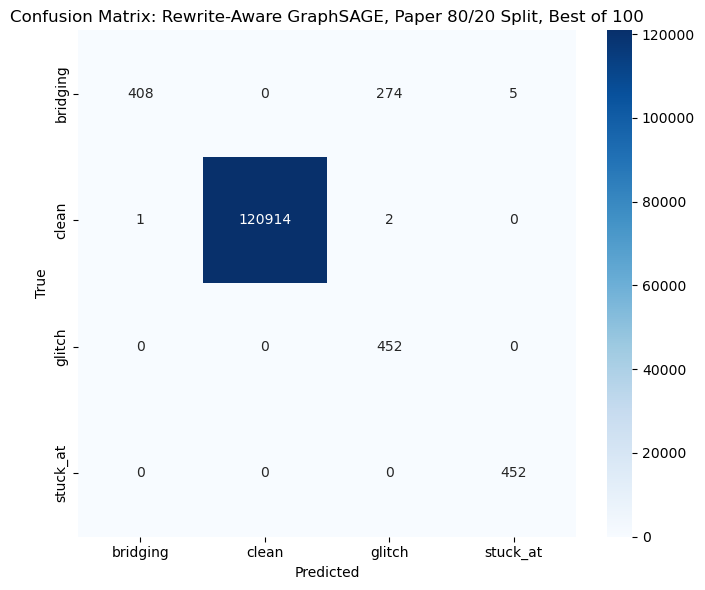


Rewrite-style stress-test diagnostic:
  Repeats: 1
  Mean perturbed test accuracy: 0.9973
  Mean perturbed test macro-F1: 0.8653

Saved checkpoint to: rewrite_aware_graphsage_paper_protocol_80_20_100epochs.pt


In [1]:
# ============================================================
# Paper-protocol Circuit-Rewrite-Aware GraphSAGE / GNN-RE-style Model
# for Circuit Fault Detection from Enhanced CSVs
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# Task:
#   Node-level 4-class classification:
#   clean, bridging, glitch, stuck_at
#
# Paper-protocol refinement:
#   - 80/20 train/test split by netlist_file
#   - no separate validation split
#   - train for 100 epochs
#   - learning rate = 7e-4
#   - dropout = 0.4
#   - hidden dimension = 64
#   - 2 GraphSAGE layers, matching the paper GraphSAGE setting
#   - paper-style class weights
#   - train-only normalization
#   - best model selected by lowest monitored test loss,
#     matching the style of the original paper-code scripts
#   - test netlist names are printed explicitly
#
# Architecture:
#   Adapted from circuit-rewriting-aware operator detection ideas:
#       - GraphSAGE-style neighborhood aggregation
#       - functionality-aware / semi-canonical local features
#       - rewrite-style training augmentation
#       - residual + LayerNorm
#       - Jumping-Knowledge-style layer fusion
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv, global_mean_pool
    from torch_geometric.utils import coalesce
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required. Install a PyG version compatible "
        "with your PyTorch/CUDA setup before running this notebook."
    ) from e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# File paths
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# Paper-code behavior:
# prefer clean topology if available; otherwise fall back to union.
EDGE_MODE = "clean"       # choices: "clean", "union"


# -------------------------
# Paper-style model hyperparameters
# -------------------------
EPOCHS = 100
LR = 7e-4
WEIGHT_DECAY = 5e-4

HID = 64
NUM_SAGE_LAYERS = 2
DROPOUT = 0.4


# -------------------------
# Training settings
# -------------------------
BATCH_SIZE = 1

MAX_FAULT_NODES_PER_CLASS_PER_GRAPH = 512
CLEAN_TO_FAULT_RATIO = 1.0

PRINT_EVERY = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# -------------------------
# Rewrite-style augmentation
# -------------------------
# This mimics structural rewriting during training.
# It is intentionally conservative:
#   - fault nodes are preserved,
#   - all node labels are preserved,
#   - only a small number of clean-region edges are dropped/shortcutted.
ENABLE_REWRITE_AUGMENTATION = True
REWRITE_AUG_PROB = 0.50
EDGE_DROP_RATE = 0.03
TWO_HOP_SHORTCUT_RATE = 0.03
MAX_SHORTCUTS_PER_GRAPH = 2000


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact",
    "dist_to_PO", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node"
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


# -------------------------
# String cleanup
# -------------------------
for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


# -------------------------
# Numeric cleanup
# -------------------------
base_num_cols = [
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Encode class labels and gate types
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError("Expected a 'clean' class in fault_type.")

clean_idx = class_to_idx["clean"]

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)


def canonical_gate_type(gate_type: str) -> str:
    """
    Paper-compatible compact gate vocabulary.

    Pseudo-fault gate names are mapped to 'other' to reduce direct leakage
    from names such as sa0, sa1, bridge, and glitch.
    """
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 netlist-level train/test split
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test split."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)


train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train n Test:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# Compatibility placeholder in case another helper cell expects val_nets.
# This notebook intentionally follows the paper's train/test-only protocol.
val_nets = np.array([], dtype=object)


# ============================================================
# 5. Graph construction helpers
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    """
    Return edges for one netlist.

    EDGE_MODE='clean':
        Use clean topology if available. This mirrors the original
        paper-code style. Fall back to union if clean topology is unavailable.

    EDGE_MODE='union':
        Use all clean + faulted topology edges, deduplicated.
    """
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    use_e = (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )

    return use_e


def coalesce_edge_index(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """
    Robust PyG coalesce wrapper across versions.
    """
    if edge_index.numel() == 0:
        return edge_index

    try:
        out = coalesce(edge_index, num_nodes=num_nodes)
    except TypeError:
        out = coalesce(edge_index, None, num_nodes, num_nodes)

    if isinstance(out, tuple):
        return out[0]

    return out


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


# ============================================================
# 6. Build one joint graph per netlist
# ============================================================

def build_joint_graphs(nets: np.ndarray) -> List[Data]:
    """
    Build one node-classification graph per netlist.

    Node set:
        Union of clean and faulted nodes.

    Labels:
        Start every node as clean.
        Any non-clean row with label==1 gets the corresponding fault_type class.

    Features:
        Gate one-hot + paper-style numeric features.
        For normal nodes, prefer clean features.
        For pseudo-fault nodes, use the fault row where label==1.
    """
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()

        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0

            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        e_use = select_edges_for_netlist(nf)

        src_list, dst_list = [], []

        if not e_use.empty:
            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s in id2idx and d in id2idx:
                    src_list.append(id2idx[s])
                    dst_list.append(id2idx[d])

        if len(src_list) > 0:
            edge_index_directed = torch.tensor([src_list, dst_list], dtype=torch.long)
        else:
            edge_index_directed = torch.empty((2, 0), dtype=torch.long)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index_directed,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.edge_index_directed = edge_index_directed.clone()
        data.netlist_file = nf

        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))


print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 7. Append relational + rewrite-aware functionality features
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    """
    Count unique nodes reachable within <=K hops for every node.
    """
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt

            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt

        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def rewrite_aware_local_features(x: torch.Tensor, edge_index_directed: torch.Tensor) -> np.ndarray:
    """
    Semi-canonical / functionality-aware local descriptors inspired by
    circuit rewriting robustness.

    These are scalable graph-local signatures available from gate-level CSVs:
      - predecessor gate-type histogram,
      - successor gate-type histogram,
      - two-hop fan-in gate histogram,
      - two-hop fan-out gate histogram,
      - fan-in / fan-out balance ratios,
      - local gate-type entropy in fan-in/fan-out cones.
    """
    N = x.size(0)
    gate_oh = x[:, :GATE_DIM].cpu().numpy().astype(np.float32)

    in_adj, out_adj = build_adj_lists(edge_index_directed, N)

    pred_hist = np.zeros((N, GATE_DIM), dtype=np.float32)
    succ_hist = np.zeros((N, GATE_DIM), dtype=np.float32)
    in2_hist = np.zeros((N, GATE_DIM), dtype=np.float32)
    out2_hist = np.zeros((N, GATE_DIM), dtype=np.float32)

    in_deg = np.zeros(N, dtype=np.float32)
    out_deg = np.zeros(N, dtype=np.float32)

    fanin_ratio = np.zeros(N, dtype=np.float32)
    fanout_ratio = np.zeros(N, dtype=np.float32)
    local_balance = np.zeros(N, dtype=np.float32)
    in_entropy = np.zeros(N, dtype=np.float32)
    out_entropy = np.zeros(N, dtype=np.float32)

    def entropy_from_hist(hist):
        s = float(hist.sum())
        if s <= 0.0:
            return 0.0
        p = hist / s
        p = p[p > 0]
        return float(-(p * np.log(p + 1e-12)).sum())

    for u in range(N):
        preds = in_adj[u]
        succs = out_adj[u]

        in_deg[u] = float(len(preds))
        out_deg[u] = float(len(succs))

        if preds:
            pred_hist[u, :] = gate_oh[preds, :].sum(axis=0)

        if succs:
            succ_hist[u, :] = gate_oh[succs, :].sum(axis=0)

        in2 = set()
        for p in preds:
            for pp in in_adj[p]:
                if pp != u:
                    in2.add(pp)

        out2 = set()
        for s in succs:
            for ss in out_adj[s]:
                if ss != u:
                    out2.add(ss)

        if in2:
            in2_hist[u, :] = gate_oh[list(in2), :].sum(axis=0)

        if out2:
            out2_hist[u, :] = gate_oh[list(out2), :].sum(axis=0)

        total = in_deg[u] + out_deg[u] + 1e-6

        fanin_ratio[u] = in_deg[u] / total
        fanout_ratio[u] = out_deg[u] / total
        local_balance[u] = abs(in_deg[u] - out_deg[u]) / total

        in_entropy[u] = entropy_from_hist(pred_hist[u, :] + in2_hist[u, :])
        out_entropy[u] = entropy_from_hist(succ_hist[u, :] + out2_hist[u, :])

    scalar_features = np.stack(
        [
            fanin_ratio,
            fanout_ratio,
            local_balance,
            in_entropy,
            out_entropy,
        ],
        axis=1,
    ).astype(np.float32)

    return np.concatenate(
        [
            pred_hist,
            succ_hist,
            in2_hist,
            out2_hist,
            scalar_features,
        ],
        axis=1,
    ).astype(np.float32)


def append_relational_and_rewrite_features(data: Data) -> Data:
    """
    Append:
      1. relational SCOAP/fanout/k-hop features,
      2. rewrite-aware local functionality signatures.
    """
    x = data.x.clone().float()
    N = x.size(0)

    edge_index_directed = data.edge_index_directed

    in_adj, out_adj = build_adj_lists(edge_index_directed, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    # Neighbor SCOAP means.
    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    # Deltas.
    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    # K-hop counts.
    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    rewrite_stack = rewrite_aware_local_features(
        x=x,
        edge_index_directed=edge_index_directed,
    )

    data.x = torch.cat(
        [
            x,
            torch.from_numpy(rel_stack),
            torch.from_numpy(rewrite_stack),
        ],
        dim=1,
    )

    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_and_rewrite_features(graph_list[i])

print("Input dimension after relational + rewrite-aware features:", train_graphs[0].x.size(1))


# ============================================================
# 8. Add reverse edges for GraphSAGE message passing
# ============================================================

def add_reverse_edges(graphs: List[Data]) -> List[Data]:
    """
    GraphSAGE uses the final edge_index for message passing.
    Add reverse edges so both fan-in and fan-out context are visible.
    """
    for g in graphs:
        if g.edge_index_directed.numel() == 0:
            g.edge_index = torch.empty((2, 0), dtype=torch.long)
            continue

        ei = g.edge_index_directed
        rev_ei = ei.flip(0)
        both = torch.cat([ei, rev_ei], dim=1)

        g.edge_index = coalesce_edge_index(both, num_nodes=g.num_nodes)

    return graphs


train_graphs = add_reverse_edges(train_graphs)
test_graphs = add_reverse_edges(test_graphs)


# ============================================================
# 9. Normalize node features using train split only
# ============================================================

def fit_node_normalizer(graphs: List[Data]):
    # Do not normalize the first GATE_DIM one-hot columns.
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)

print("Final node input dimension:", train_graphs[0].x.size(1))


# ============================================================
# 10. Print final model-level class distributions
# ============================================================

def labels_from_graphs(graphs: List[Data]) -> np.ndarray:
    return np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)


train_labels_all = labels_from_graphs(train_graphs)
test_labels_all = labels_from_graphs(test_graphs)


def print_final_counts(split_name: str, labels: np.ndarray):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{split_name} final joint-graph class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_final_counts("Train", train_labels_all)
print_final_counts("Test", test_labels_all)


# ============================================================
# 11. Paper-style class weights
# ============================================================

cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)

weights_np = cls_counts.max() / (cls_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)

print("\nClass weights:", class_weights.detach().cpu().numpy())


# ============================================================
# 12. Rewrite-style graph augmentation
# ============================================================

def rewrite_style_augment_graph(data: Data) -> Data:
    """
    Conservative rewrite-style augmentation.

    It perturbs the message-passing topology in clean regions:
      - randomly drops a small fraction of clean-to-clean edges,
      - optionally adds a small number of two-hop shortcut edges,
      - preserves all edges touching fault nodes.

    This is only used during training. Test uses original graphs.
    """
    if not ENABLE_REWRITE_AUGMENTATION:
        return data

    if random.random() > REWRITE_AUG_PROB:
        return data

    if data.edge_index.numel() == 0:
        return data

    y = data.y.detach().cpu().numpy()
    ei = data.edge_index.detach().cpu()

    src = ei[0].numpy()
    dst = ei[1].numpy()

    edge_count = ei.size(1)
    keep_mask = np.ones(edge_count, dtype=bool)

    # Drop only clean-to-clean edges.
    clean_to_clean = (y[src] == clean_idx) & (y[dst] == clean_idx)

    drop_candidates = np.flatnonzero(clean_to_clean)

    if len(drop_candidates) > 0 and EDGE_DROP_RATE > 0:
        k_drop = int(math.floor(EDGE_DROP_RATE * len(drop_candidates)))

        if k_drop > 0:
            drop_idx = np.random.choice(drop_candidates, size=k_drop, replace=False)
            keep_mask[drop_idx] = False

    new_src = src[keep_mask].tolist()
    new_dst = dst[keep_mask].tolist()

    # Two-hop shortcut edges among clean nodes.
    if TWO_HOP_SHORTCUT_RATE > 0 and MAX_SHORTCUTS_PER_GRAPH > 0:
        out_adj = [[] for _ in range(data.num_nodes)]

        for s, d in zip(src, dst):
            out_adj[int(s)].append(int(d))

        shortcut_budget = min(
            MAX_SHORTCUTS_PER_GRAPH,
            int(math.ceil(TWO_HOP_SHORTCUT_RATE * edge_count)),
        )

        shortcuts = set()
        attempts = 0
        max_attempts = shortcut_budget * 20 + 100

        clean_nodes = np.flatnonzero(y == clean_idx)

        if len(clean_nodes) > 0:
            while len(shortcuts) < shortcut_budget and attempts < max_attempts:
                attempts += 1

                u = int(np.random.choice(clean_nodes))

                if len(out_adj[u]) == 0:
                    continue

                mid = int(np.random.choice(out_adj[u]))

                if len(out_adj[mid]) == 0:
                    continue

                v = int(np.random.choice(out_adj[mid]))

                if u == v:
                    continue

                if y[u] != clean_idx or y[v] != clean_idx:
                    continue

                shortcuts.add((u, v))
                shortcuts.add((v, u))

        for s, d in shortcuts:
            new_src.append(s)
            new_dst.append(d)

    new_edge_index = torch.tensor([new_src, new_dst], dtype=torch.long)

    new_edge_index = coalesce_edge_index(
        new_edge_index,
        num_nodes=data.num_nodes,
    )

    aug_data = Data(
        x=data.x,
        edge_index=new_edge_index,
        y=data.y,
    )

    if hasattr(data, "netlist_file"):
        aug_data.netlist_file = data.netlist_file

    return aug_data


# ============================================================
# 13. GraphSAGE rewrite-aware model
# ============================================================

class RewriteAwareGraphSAGE(nn.Module):
    """
    Circuit-rewrite-aware GraphSAGE model.

    Main ideas:
      - GraphSAGE-style mean aggregation,
      - residual connections and LayerNorm,
      - Jumping-Knowledge-style fusion,
      - graph-level context broadcast to nodes.
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        num_layers: int = 2,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                SAGEConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    aggr="mean",
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.jk_proj = nn.Sequential(
            nn.Linear(hidden_dim * (num_layers + 1), hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.jk_norm = nn.LayerNorm(hidden_dim)

        self.graph_context_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.node_graph_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.fusion_norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index

        h = self.input_proj(x)
        h = self.input_norm(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        states = [h]

        for conv, norm in zip(self.convs, self.norms):
            if edge_index.numel() == 0:
                h_msg = h
            else:
                h_msg = conv(h, edge_index)

            h = norm(h + F.dropout(h_msg, p=self.dropout_p, training=self.training))
            h = F.elu(h)

            states.append(h)

        h_cat = torch.cat(states, dim=-1)

        h_jk = self.jk_proj(h_cat)
        h_jk = self.jk_norm(states[-1] + h_jk)
        h_jk = F.elu(h_jk)

        if hasattr(data, "batch") and data.batch is not None:
            batch = data.batch
        else:
            batch = torch.zeros(
                h_jk.size(0),
                dtype=torch.long,
                device=h_jk.device,
            )

        h_graph = global_mean_pool(h_jk, batch)
        h_graph = self.graph_context_proj(h_graph)
        h_graph_for_node = h_graph[batch]

        h_fused = self.node_graph_fusion(
            torch.cat([h_jk, h_graph_for_node], dim=-1)
        )

        h_final = self.fusion_norm(h_jk + h_fused)
        h_final = F.elu(h_final)

        logits = self.classifier(h_final)

        return logits


in_dim = train_graphs[0].x.size(1)

model = RewriteAwareGraphSAGE(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    num_layers=NUM_SAGE_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print("\nModel:")
print(model)
print("\nRewrite-style augmentation enabled:", ENABLE_REWRITE_AUGMENTATION)


# ============================================================
# 14. Training and evaluation helpers
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

rng = np.random.default_rng(SEED)


def sample_balanced_idx(
    y: torch.Tensor,
    max_fault_per_class: int = 512,
    clean_to_fault_ratio: float = 1.0,
):
    """
    Paper-style balanced node subset for the loss.

    Evaluation is always done on all nodes.
    """
    y_np = y.detach().cpu().numpy()

    selected = []
    total_fault_selected = 0

    for c in range(num_classes):
        if c == clean_idx:
            continue

        c_idx = np.flatnonzero(y_np == c)

        if len(c_idx) == 0:
            continue

        k = min(len(c_idx), max_fault_per_class)
        chosen = rng.choice(c_idx, size=k, replace=False)
        selected.append(chosen)
        total_fault_selected += k

    clean_candidates = np.flatnonzero(y_np == clean_idx)

    if total_fault_selected > 0 and len(clean_candidates) > 0:
        k_clean = min(
            len(clean_candidates),
            int(math.ceil(clean_to_fault_ratio * total_fault_selected)),
        )

        chosen_clean = rng.choice(clean_candidates, size=k_clean, replace=False)
        selected.append(chosen_clean)

    if not selected:
        all_idx = np.arange(len(y_np))
        k = min(len(all_idx), 512)
        chosen = rng.choice(all_idx, size=k, replace=False)
        selected.append(chosen)

    selected = np.unique(np.concatenate(selected))

    return torch.tensor(selected, dtype=torch.long, device=DEVICE)


def train_one_epoch(graphs: List[Data]):
    model.train()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    for data in loader:
        # Apply rewrite-style augmentation before moving to device.
        data = rewrite_style_augment_graph(data)
        data = data.to(DEVICE)

        logits = model(data)

        idx = sample_balanced_idx(
            data.y,
            max_fault_per_class=MAX_FAULT_NODES_PER_CLASS_PER_GRAPH,
            clean_to_fault_ratio=CLEAN_TO_FAULT_RATIO,
        )

        loss = F.cross_entropy(
            logits[idx],
            data.y[idx],
            weight=class_weights,
            reduction="mean",
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            pred = logits[idx].argmax(dim=1)
            total_correct += int((pred == data.y[idx]).sum().item())
            total_seen += int(idx.numel())
            total_loss += float(loss.item()) * int(idx.numel())

    avg_loss = total_loss / max(1, total_seen)
    sampled_acc = total_correct / max(1, total_seen)

    return avg_loss, sampled_acc


@torch.no_grad()
def evaluate_graphs(graphs: List[Data]):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    y_true = []
    y_pred = []

    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)

        loss = F.cross_entropy(
            logits,
            data.y,
            weight=class_weights,
            reduction="mean",
        )

        pred = logits.argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    avg_loss = total_loss / max(1, total_nodes)

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="weighted",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


# ============================================================
# 15. Train for fixed 100 epochs, keep best monitored test loss
# ============================================================

best_state = None
best_test_loss = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc = train_one_epoch(train_graphs)

    # Paper-code style: monitor held-out test graphs during training.
    test_metrics_during_training = evaluate_graphs(test_graphs)

    if test_metrics_during_training["loss"] < best_test_loss:
        best_test_loss = float(test_metrics_during_training["loss"])
        best_epoch = int(epoch)
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss_sampled={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_loss={best_test_loss:.4f} "
            f"best_epoch={best_epoch}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nTraining complete.")
print(f"Best monitored test loss across 100 epochs: {best_test_loss:.6f}")
print(f"Best epoch: {best_epoch}")


# ============================================================
# 16. Final train/test metrics
# ============================================================

train_final = evaluate_graphs(train_graphs)
test_final = evaluate_graphs(test_graphs)

print("\nFinal Accuracy Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Accuracy: {train_final['acc']:.4f}")
print(f"Test Accuracy:     {test_final['acc']:.4f}")

print("\nFinal Macro-F1 Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Macro-F1: {train_final['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_final['macro_f1']:.4f}")

print("\nFinal Weighted-F1 Summary, best model across 100 epochs")
print("-------------------------------------------------------")
print(f"Training Weighted-F1: {train_final['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_final['weighted_f1']:.4f}")


# ============================================================
# 17. Test classification report and confusion matrix
# ============================================================

y_true = test_final["y_true"]
y_pred = test_final["y_pred"]

print("\nTest Classification Report, best model across 100 epochs:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nTest Confusion Matrix, best model across 100 epochs:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: Rewrite-Aware GraphSAGE, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: Rewrite-Aware GraphSAGE, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()


# ============================================================
# 18. Optional: compare test result under light rewrite perturbation
# ============================================================

@torch.no_grad()
def evaluate_rewrite_stress(graphs: List[Data], repeats: int = 1):
    """
    Optional robustness diagnostic:
    evaluates the trained model after applying the same conservative
    rewrite-style topology perturbation to test graphs.

    This is not the main test metric.
    """
    global ENABLE_REWRITE_AUGMENTATION

    old_flag = ENABLE_REWRITE_AUGMENTATION
    ENABLE_REWRITE_AUGMENTATION = True

    all_acc = []
    all_macro = []

    for _ in range(repeats):
        perturbed_graphs = [rewrite_style_augment_graph(g) for g in graphs]
        metrics = evaluate_graphs(perturbed_graphs)

        all_acc.append(metrics["acc"])
        all_macro.append(metrics["macro_f1"])

    ENABLE_REWRITE_AUGMENTATION = old_flag

    print("\nRewrite-style stress-test diagnostic:")
    print(f"  Repeats: {repeats}")
    print(f"  Mean perturbed test accuracy: {np.mean(all_acc):.4f}")
    print(f"  Mean perturbed test macro-F1: {np.mean(all_macro):.4f}")


evaluate_rewrite_stress(test_graphs, repeats=1)


# ============================================================
# 19. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "rewrite_aware_graphsage_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_test_loss": best_test_loss,
            "config": {
                "model": "RewriteAwareGraphSAGE",
                "protocol": "paper_style_80_20_train_test_split",
                "hidden_dim": HID,
                "num_sage_layers": NUM_SAGE_LAYERS,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "epochs": EPOCHS,
                "edge_mode": EDGE_MODE,
                "rewrite_augmentation": {
                    "enabled": ENABLE_REWRITE_AUGMENTATION,
                    "probability": REWRITE_AUG_PROB,
                    "edge_drop_rate": EDGE_DROP_RATE,
                    "two_hop_shortcut_rate": TWO_HOP_SHORTCUT_RATE,
                    "max_shortcuts_per_graph": MAX_SHORTCUTS_PER_GRAPH,
                },
                "rewrite_features": [
                    "predecessor_gate_type_histogram",
                    "successor_gate_type_histogram",
                    "two_hop_fanin_gate_histogram",
                    "two_hop_fanout_gate_histogram",
                    "fanin_ratio",
                    "fanout_ratio",
                    "local_balance",
                    "fanin_entropy",
                    "fanout_entropy",
                ],
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")